# Random Variables

**Definition: Random Variable** 

A random variable is a function from a sample space to R. 

Note: The randomness of the random variable comes from it's pre-image. The set $E = \{ x \in S: X(s) = a \}$ is an event, and we can take P(E) as the probability of the random variable taking a value a. Or an event like : $E = \{ x \in S: a < X(s) < b \}$ is an event and P(E) is the probability that the random variable will take a value between a and b. Thus, P, the probability function on the sample space, really drives the "randomness" of the random variable, which is otherwise just a plain vanilla function.

We can write $P(X = x) = P(\{s \in S: X(s) = x\})$, $P(X < x) = P(\{s \in S: X(s) < x\})$, etc. Note that P(X) would make no sense - Probabiity is only defined on the subsets of S.


# Distributions and Probability Mass Functions

**Definition: Discrete Random Variable**

An r.v is said to be discrete if it takes on a countable number of values. 

The set of countable values x of an r.v. X, such that P(X = x) > 0, is called the **support** of X. 

The **distribution** of an r.v. describes the behaviour of the random variable.

**Definition: (Probability Mass Function)**

The probability mass function (PMF) of a discrete r.v. X is the function $p_X(x) = P(X = x)$. Note that this is positive if x is in the support of X, 0 otherwise.



In [2]:
import itertools
import numpy as np
from sympy import Eq, Symbol, LessThan, GreaterThan, And, Rational
from scipy.stats import randint
from sympy.stats import Die, Coin, density, P, E, sample
import matplotlib.pyplot as plt

def plot_discrete_pmf(ax, xaxis, xlabels, pmf, *, ms:int=8, lw:int=5):
    if xlabels is not None:
        ax.set_xticks(xaxis, xlabels)
    ax.plot(xaxis, pmf, 'bo', ms=ms, label='randint pmf')
    ax.vlines(xaxis, 0, pmf, colors='b', lw=lw, alpha=0.5)


def plot_discrete_pmf_rv(ax, rv, **kw_args):
    den = density(rv)
    xlabels = np.array(list(den.keys()))
    xaxis = np.arange(0,xlabels.size)
    pmf = np.array(list(den.values()))
    plot_discrete_pmf(ax, xaxis, xlabels, pmf, **kw_args)


def plot_discrete_pmf_distribution(ax, distribution, *, start_index=None, end_index=None, **kw_args):
    den = density(distribution).dict
    pmf = np.array(list(den.values())[start_index: end_index])
    xaxis = list(den.keys())[start_index:end_index]

    plot_discrete_pmf(ax, xaxis, None, pmf, **kw_args)


def plot_discrete_cdf(ax, cdf, *, ms:int=8, lw:int=5):
    xaxis = list(cdf.keys())
    values = list(cdf.values())

    xaxis.insert(0, xaxis[0])
    values.insert(0, 0)

    ax.plot(xaxis, values, ms=ms, label='cdf', drawstyle='steps-post')
    # ax.vlines(xaxis, 0, values, colors='b', lw=lw, alpha=0.5)

def discrete_cdf_from_rv(rv):
    pmf = density(rv).dict
    return dict(zip(pmf.keys(), np.cumsum([float(i) for i in pmf.values()])))



H + T

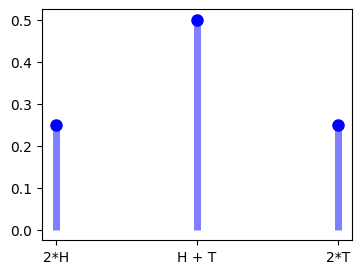

In [3]:
# PMF SAMPLE
fig, ax = plt.subplots(1, 1, figsize=(4,3))

X1 = Coin('X1')
X2 = Coin('X2')

X = X1 + X2
plot_discrete_pmf_rv(ax, X)

E(X)



{2 - 2*H: 1/4, -H - T + 2: 1/2, 2 - 2*T: 1/4}


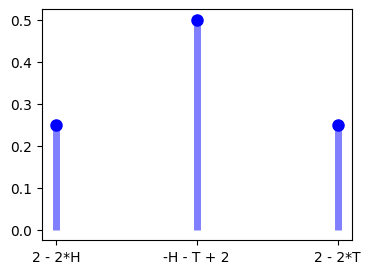

In [4]:
fig, ax = plt.subplots(1, 1,  figsize=(4,3))

Y = 2 - X

print(density(Y).dict)

plot_discrete_pmf_rv(ax, Y)

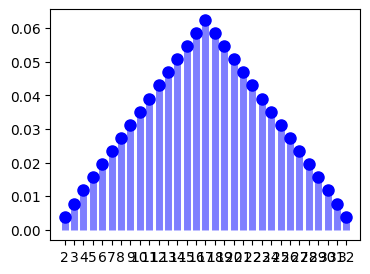

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(4,3))

X = Die('X', 16)
Y = Die('Y', 16)

T = X + Y
plot_discrete_pmf_rv(ax, T)

In [6]:
P(And(GreaterThan(T,1), LessThan(T,4)))

1/6

# Theorem 3.2.7 (Valid PMFs): Any valid PMF must satisfy two criteria:

Let X be a valid r.v.on a sample space s, with support $x_1, x_2, \dots$ - assume the support is countable, and $x_j$ are distict. The PMF $p_X$ of X must satisfy 2 criteria:

- Nonnegative: $p_X(x) > 0$ if $x = x_j$ for some j, and $p_X(x) = 0$ otherwise.
- Sums to 1: $\sum\limits_{j=1}^{\infty} p_X(x_j) = 1$

Proof:

Probability is non-negative. Also, since $x_1, x_2, \dots$, and X is a function from the sample space to R, the inverse images (events) for each $x_j$ are disjoint. 

If S is the sample space, then $S = \bigcup\limits_{j=1}^{\infty} \{x \in S: X(s) = x_j\} \cup \{x \in S: X(s) = 0\}$ It follows then, that:

Then, $P(S) = 1 = P(\bigcup\limits_{j=1}^{\infty} \{x \in S: X(s) = x_j\} \cup \{x \in S: P(\{x\}) = 0\}) = P(\bigcup\limits_{j=1}^{\infty} \{x \in S: X(s) = x_j\}) = \sum\limits_{j=1}^{\infty} P(X=x_j) = \sum\limits_{j=1}^{\infty} p_X(x_j)$


# Bernoulli and Binomial

**Definition: (Bernoulli Distribution)**

An r.v. X is said to have the Bernoulli distribution with parameter p if P(X = 1) = p and P(X = 0) = 1 - p, where 0 < p < 1. We write this as $X \thicksim Bern(p)$ i.e. X is distributed as a Bernoulli with parameter p.

**Definition: Indicator Random Variable**

An indicator random variable is associated with a particular event, and it's value is 1 if the event occurs, and 0 otherwise. Basically given an event A in a sample space S, the indicator random variable is a function $I_A$, such that:

$$I_A:S \to R: x \to \begin{cases} 1 \text{ if } x \in A  \\ 0 \text{ if } x \notin A \end{cases}$$

If P(A) = p, then $I_A \thicksim Bern(p)$. 

If we classify an experiment into two categories - success and failure, and A is the event that the trial is a success, then $I_A$ is then an indicator of the success of the experiment. This is often the sense in which indicator variables are used. In this case, the parameter p is called the **success probability** of the **Bern(p)** distribution.

**Definition(Binomial Distribution)** 

Suppose that n independent Bernoulli trials are performed, each with same success probability p. Let X be an r.v. giving the number of successes in the n experiments. The distribution of X is called the Binomial Distribution with parameters n and p. We write $X \thicksim Binom(n,p)$ to mean that X has the Binomial distribution with parameters n and p, where n is a positive integer and 0 < p  < 1.

Note that $Bern(p) = Bin(1,p)$.


**Theorem(Binomial PMF)**

If $X \thicksim Bin(n,p)$, then the PMF of X is :

$$P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$$

Proof (That this is a valid PMF): 

$\sum\limits_{k=1}^{n} \binom{n}{k}p^k(1-p)^{n-k} = (p + (1 - p))^{k + n - k} = 1^n = 1$ by the Binomial theorem.


**Theorem: If $X \thicksim Binom(n,p), \text{ then } n - X \thicksim Binom(n,q), \text{ where } q = 1-p$**

Proof: Immediate from definition.

**Theorem: (Symmetry if p = 1/2) $X \thicksim Binom(n,1/2)$ is symmetrical about n/2 i.e. P(X = n/2-j) = P(X = n/2+j) for all non-negative integers j**

$\binom{n}{k}p^k(1-p)^{n-k}$

If n is odd, $\binom{n}{\lfloor n/2\rfloor - j} = \binom{n}{\lceil n/2 \rceil + j}$, for j = 0 to $\lfloor n/2 - j \rfloor$. If n is even, $\binom{n}{n/2 - j} = \binom{n}{n/2 + j}$ for j = 0 to n/2.

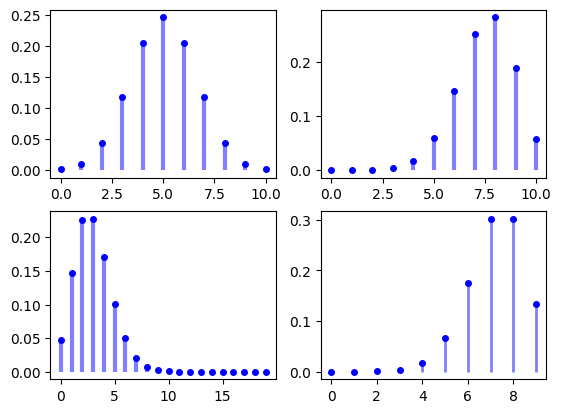

In [7]:
from sympy.stats import Binomial, density
from sympy import S, Symbol

fig, ax = plt.subplots(2, 2)

plot_discrete_pmf_distribution(ax[0][0], Binomial('X', 10, S.Half), ms=4, lw=3)

plot_discrete_pmf_distribution(ax[0][1], Binomial('X', 10, 3/4), ms=4, lw=3)

plot_discrete_pmf_distribution(ax[1][0], Binomial('X', 100, 0.03), end_index=20, ms=4, lw=3) 

plot_discrete_pmf_distribution(ax[1][1], Binomial('X', 9, 4/5), ms=4, lw=2)


# Hypergeometric Distribution

Story: An urn has w white balls, and b black balls. n balls are drawn (*sampling without replacement*). How many white balls are in the sample?

This number follows the **hypergeometric distribution**. 

The classic story behind this distribution is the *elk* problem. There are b untagged and w "tagged" elks in the forest. We randomly catch n elks for retagging - how many of the elks had been already tagged? 

Another example is picking hands from deck of cards. I pick a five card hand from a deck. How many aces do i have? Here we can say we have w = 4, b = 48, n = 5.

The basic story is about about partitioning a set in 2 ways, of which one is randomly sampled (without replacement) from overall set.

a) For urns, we have the black/white partition, and a "sampled", "not sampled" partition and we are looking for an overlap between whites and the sampled tag.

b) For elks, we have elks who were tagged / untagged the first time, and those who were tagged / untagged the second time and seeing the overlap of those elks who are tagged two times.

c) For aces, we we have aces / non-aces in the deck, and then selected / not-selected in the hand. 

**Theorem: (Hypergeometric Distribution PMF)**

If $X \thicksim HGeom(w,b,n)$, then the PMF of X is:

$$P(X = k) = \frac{\binom{w}{k}\binom{b}{n-k}}{\binom{w+b}{n}}$$

With $0 \le k \le w$, $0 \le n - k \le b$, and $P(X = x)$ = 0 otherwise.

Proof (valid PMF):

By Vandermonde's identity, we get $\sum\limits_{k=0}^{w} \binom{w}{k}\binom{b}{n-k} = \binom{w + b}{k + (n-k)} = \binom{w + b}{n}$

$$
\sum\limits_{k=0}^{w} \frac{\binom{w}{k}\binom{b}{n-k}}{\binom{w+b}{n}} = \frac{1}{\binom{w+b}{n}} \sum\limits_{k=0}^{w} \binom{w}{k}\binom{b}{n-k} = \frac{\binom{w+b}{n}}{\binom{w+b}{n}} = 1
$$



**Theorem 3.4.5 : Suppose $X \thicksim HGeom(w,b,n)$ is a distribution. Let $Y \thicksim HGeom(n, w + b -n, w)$. Then P(X = k) = P(Y = k) for all k in R i.e. X and Y have the same distribution.**

**Story Proof:**

Suppose we have N black balls in an urn. We pick m of these (without replacement) and paint them white, leaving N-m black. We then pick n balls again and paint green stripes on them. X = HGeom(m,N-m,n) give the probability that k of the balls are both white and have green stripes.

Now we reverse the procedure. We have n, and N-n balls with / without green stripes. Then we pick m balls to paint white (carefully not painting over the green stripes, if any!). How many balls are both green and have white stripes? The two selections are independent of each other and the order of selection does not matter. Hence we should expect that given Y = HGeom(n,N-n,m), P(Y=k) = P(X = k).

Two people are working with an urn containing N black balls, one at a time. The first person's job is to pick one ball not painted half-white on any black side, and put it back. The other person's job is to pick a ball not yet painted green and paint it green on any black side. Only one ball is taken out of the urn at any time (i.e. only one person is sampling at a time, and the other waits till they put the ball back). They work for one hour and at the end there are m balls painted white, and n balls painted green. How many balls are painted both green and white? Clearly X = HGeom(m,N-m,n), or HGeom(n, N-n, m) giving the same result. The main point is the chronological order of sampling should have no impact on the value of k, since the two samplings are independent.

**Algebraic Proof:**

$P(Y = k) = \frac{\binom{n}{k}\binom{w + b -n}{w-k}}{\binom{w+b}{w}} = \frac{n!(w + b - n)!w!b!}{k!(n-k)!(w-k)!(b - n + k)!(w + b)!} = \frac{(w!/k!(w-k)!)(b!/(n-k)!(b - n + k)!)}{(w + b)!/n!(w+b-n)!} = \frac{\binom{w}{k}\binom{b}{n-k}}{\binom{w+b}{n}}$





In [8]:
from sympy.stats import Hypergeometric

## Note that here N=w+b, m = w, and 

# Pick 5 cards from a deck of 52, with 4 aces.

X = Hypergeometric('X', 52,4,5)

# Probability of 3 aces approx 0.17%
float(P(Eq(X,3)))



0.0017360790470034167

## Binomial vs Hypergeometric

Imagine we have n=w white and b black balls in an urn. We define success as picking a white ball. Then the probability of success is p = w/w+b.

If we sample with replacement, the probability stays constant. The probability of "k" successes is given by Binom(n=w+b,p=w/w+b). The Bernoulli trials are independent.

If we sample without replacement, the probability keeps changing with each sample - the Bernoulli trials are dependent. The probability of k successes is given by HGeom(w,b,n). 



# Discrete Uniform Distribution

A throw of a single dice gives numbers 1 to 6 with equal probability. i.e. P(3) = P(5) etc. This is not true if we throw two dice, and take the sum. 

**Definition(Discrete Uniform Distribution)**

Let C be a finite, non-empty set of numbers. Choose one of these numbers uniformly at random - call the chosen number X. Then X is said to have the Discrete Uniform distribution with parameter C : $X \thicksim DUnif(C)$.

The pmf of X:

$P(X = x) = \begin{cases} \frac{1}{|C|} \text{ if } x \in C \\ 0 \text { otherwise } \end{cases}$

If A is an event (a subset of C): $P(X \in A) = \frac{|A|}{|C|}$


In [9]:
from sympy import symbols
from sympy.stats import DiscreteUniform

X = DiscreteUniform('X', symbols('a b c'))
print(density(X).dict)

Y = DiscreteUniform('Y', list(range(5)))
print(density(Y).dict)

Z = Die('Z', 6)
print(density(Z).dict)


{b: 1/3, c: 1/3, a: 1/3}
{0: 1/5, 1: 1/5, 2: 1/5, 3: 1/5, 4: 1/5}
{1: 1/6, 2: 1/6, 3: 1/6, 4: 1/6, 5: 1/6, 6: 1/6}


## Ex: Random Slips of Paper

100 slips of paper, numbered 1 to 100, in a hat. Five slips are drawn, one at a time.

**Sampling with Replacement**

a) What is the distribution of the how many slips have a value of at least 80 written on them?

Since this is sampling w/ replacement, and every sample is an independent Bern(0.21) trial, the distribution is Binom(5,.21)

b) What is the distribution for the jth draw?

$X_j = DUnif(\{1,2,\dots,100\})$, since in each draw, each outcome is equally likely. 

c) Probability 100 is drawn at least once?

Distribution = Binom(5,0.01), $P(X >= 1)$

Alternately, using the $X_j's$: Here $A = \{1,\dots, 99\} \subset C = \{1,\dots, 99, 100\}$

$P(X_j = 100 \text{ at least one j }) = 1 - P(X_1 \in A, X_j \in A, \dots, X_5 \in A) = 1 - (\frac{|A|}{|C|})^5 = 1 - (\frac{99}{100})^5$.

In the last step, we are using the fact that the $X_j$'s are independent.

In [10]:
X = Binomial('X', 5,0.01)
print("Sampling w/ Replacement: P(At least one Ace)", P(GreaterThan(X,1)))

X = []

for i in range(1,6):
    X.append(DiscreteUniform(f"X{i}", list(range(1,101))))

print("Sampling w/ Replacement: P(At least one Ace)", 1-P(X[0] < 100)*P(X[1] < 100)*P(X[2] < 100)*P(X[3] < 100)*P(X[4] < 100))

Sampling w/ Replacement: P(At least one Ace) 0.0490099501000000
Sampling w/ Replacement: P(At least one Ace) 490099501/10000000000


**Sampling with Replacement**

a) What is the distribution of the how many slips have a value of at least 80 written on them?

Since this is sampling w/ replacement, we have 5 Bernoulli trials but which are not independent. So distribution is HGeom(21,79,5).

b) Distribution of the jth draw?

This is the most important point.

$Y_j = DUnif(\{1,2,\dots, 100\})$!

There is no conceptual difference between sampling one-by-one, and putting 5 hands simultaenously and pulling 5 slips of paper. By symmetry, every slip of paper is equally likely to be in any sample, hence the distribution is uniform. 


c) Probability number 100 is drawn (note that it can only be drawn once)

distribution = HGeom(1,99,5).

Alternatively, using the $Y_j$'s $Y_j$'s are disjoint (opposite of independent):

P(Ace being drawn) = $P(Y_1 = 100) + P(Y_2 = 100) + P(Y_3 = 100) + P(Y_4 = 100) + P(Y_5 = 100) = 0.01*5 = 0.05$ 



In [11]:
X = Hypergeometric('X', 100,1,5)
print("Sampling without Replacement: P(One Ace)", float(P(Eq(X,1))))

Y = []

for i in range(1,6):
    Y.append(DiscreteUniform(f"Y{i}", list(range(1,101))))

print("Sampling without Replacement: P(One Ace)", P(Eq(Y[0],100)) + P(Eq(Y[1],100)) + P(Eq(Y[2],100)) + P(Eq(Y[3],100)) + P(Eq(Y[4],100)))

Sampling without Replacement: P(One Ace) 0.05
Sampling without Replacement: P(One Ace) 1/20


# Cumulative Distribution Function (CDF)



**Definition**

The CDF of an r.v is the function $F_X(x) = P(X \le x)$. 

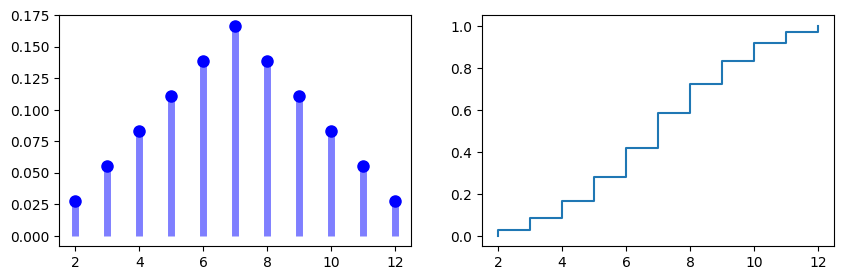

In [12]:
from sympy.stats import cdf

fig, ax = plt.subplots(1, 2, figsize=(10,3))

X = Die('X', 6)
Y = Die('Y', 6)

C = X + Y
plot_discrete_pmf_distribution(ax[0], X+Y)
plot_discrete_cdf(ax[1], discrete_cdf_from_rv(C))


The flat regions in a cdf correspond to regions outside the support of the random variable.

**Theorem (Valid CDF's)**

Any CDF F has the following properties:

- Increasing : If $x_1 \le x_2, F(x_1) \le F(x_2)$. 
- Right-continuous: $F(a) = \lim_{x \to a+} F(x)$ - whenever there is a jump, the CDF is continuous from the right
- Convergence to 0 and 1 in the limits: $\lim_{x \to -\infty} F(x) = 0$, $\lim_{x \to +\infty} F(x) = 1$

**Proof(for Discrete)**

Let X be a discrete random variable, with support $\{x_1, x_2, \dots, x_n, \dots \}$, with $x_n$ increasing, and unique.

Increasing: Since the event $\{X \lt x_1\} \subset \{X \lt x_2\}$, $P(X \lt x_1) \lt P(X \lt x_2)$. 

Right-Continuous: Proved later. A rough argument is that given any n, $x_n \lt x_{n+1}$, and for all x between $x_n$ and $x_{n+1}$, $P(X \le x) = P(X \le x_n)$. Thus it follows that for 0 < h < $x_{n+1} - x_n$, $\lim_{h \to 0} P(X \lt x_n + h) = P(X \lt x_n)$.
Convergence to 0 & 1 in the limits: This is fairly obvious at one end: We have $P(X \lt x_0) = 0$ by definition. At the other end, 

$\lim_{x \to \infty} P(X \le x) = \lim_{n \to \infty} P(X \le x_n)$, since the $x_n$ form the support of S. However, the event $\{X \le x_n\} \subset S$, and hence $P(X \le x_n) \le P(S) = 1$, for all n. 



# Functions of a Random Variable

If X is a random variable, and $g:R \to R$ is a function, then $g(X) = g \circ X$ is also a random variable.

Given the PMF of X, what is the PMF of g(X)? If g is a one-one function (at least on the support of X), then we the answer is straightforward - it's the same as X.

Thus: P(Y = g(x)) = P(X = x).



## Theorem (PMF of g(X), if not one-one)

$P(Y = y) = \sum\limits_{x:g(x) = y} P(X = x)$



## Example (Random Walk):

A particle moves n steps on number line, starting from 0, moving left/right with equal probability. All steps are independent. Let Y be particles position after n steps. Find PMF of y.

Each step is a Bern(1/2) trial - we can treat the number of steps as a random variable X, say, treating moving right as success. If X = j, then we have made n-j steps to the left, and our position is j - (n -j) = 2j -n. Hence, the random variable Y = 2X - n expresses what we need, and is a one-one function of X. 

P(Y = k) = P(2X -n = k) = P(X = (n+k)/2) = $\binom{n}{(n+k)/2}(\frac{1}{2})^n$, $-n \le k \le n$, and n+k is even.

**Not one-one function** Let D = |Y| (distance traveled from origin)

$P(D = 0) = \binom{n}{(n)/2}(\frac{1}{2})^n$

$P(D = k) = P(Y = k) + P(Y = -k) =   2\binom{n}{(n+k)/2}(\frac{1}{2})^n$

## Theorem: (Function of two r.v.s)

Given an experiment with sample space S,if X and Y are r.v.s that map s ∈ S to X(s) and Y(s) respectively, then g(X,Y) is the r.v. that maps s to g(X(s), Y (s)).

**Definition(Independence of many r.v.s)**. 

Random variables $X_1, . . . , X_n$ are independent if $P(X_1 ≤ x_1,...,X_n ≤ x_n) = P(X_1 ≤ x_1)...P(X_n ≤ x_n)$, for all $x_1, . . . , x_n$ ∈ R. For infinitely many r.v.s, we say that they are independent if every finite subset of the r.v.s is independent.


In [13]:
from sympy import Max
D1 = Die('D1', 6)

D2 = Die('D2', 6)

density(Max(D1,D2))




{1: 1/36, 2: 1/12, 3: 5/36, 4: 7/36, 5: 1/4, 6: 11/36}

# Independence of R.V.s

**Definition (Independence of r.v.'s)**

Two r.v.'s X and Y are said to be independendent if :

$P(X \le x, Y \le y) = P(X \le x)P(Y \le y)$ 

for all x,y in R.

In the discrete case this is equal to the condition:

$P(X = x, Y = y) = P(X = x)P(Y = y)$ 

**Definition (Independence of many r.v.'s)**

Random variables $X_1, X_2, \dots, X_n$ are independent if:

$P(X_1 \le x_1, X_2 \le x_2, \dots, X_2 \le x_2) = P(X \le x_1)P(X \le x_2)\dots P(X \le x_n)$ 

for all $x_1, x_2, \dots, x_n \in R$. Note that the last condition (for all x..) means that for an infinite combination of real numbers the condition must hold true.

Note: By this definition, if $X_1, X_2, \dots, X_n$ are independent, then they are also pairwise independent. This requires proof, but as a general matter, the proof requires letting the other $x_k$ go to $\infty$ since $X_k \lt \infty$ is true. 

But the other way is not true, in general. Pairwise independence does not imply independence.


## Theorem (Functions of independent r.v.'s)

If X and Y are independent r.v.'s, then any function of X is independent of any function of Y.

**Definition: (i.i.d - Independent and Identically Distributed)**

These are r.v.'s that are independent and identically distributed i.e. they have the same PMF.


Examples:

- i.i.d : X and Y are result of 2 independent die rolls.

- independent but not i.d. - X is the result of a die roll, Y is the result of a coin toss.

- dependent and i.d. - X be no of heads in a die roll, Y be no of tails in the same die roll

- dependent but not i.d. - X is the no of heads in n coin tosses, Y is the no of tails before the first head


## Theorem (Binomial as sum of i.i.d's)

If $X \thicksim Bin(n,p)$, we can write $X = X_1 + X_2 + \dots + X_n$ when each the $X_i$ are i.i.d. Bern(p).

Proof: We assume $X_1 = 1$ means trial was a success. Adding up $X_i$ is the same as the number of successes in n trials.

## Theorem (Sum of Two Binomials with same p, is Binomial)

If $X \thicksim Bin(n,p)$ and $Y \thicksim Bin(m,p)$, and **X is independent of Y**, then $X + Y \thicksim Bin(n + m, p)$

**Proof:**

$$
\begin{align*}
P(X + Y = k) &= \sum_{j=0}^{k} P(X + Y = k|X = j)P(X = j)  \text { by LOTP } \\
             &= \sum_{j=0}^{k} P(Y = k-j)P(X = j)  \text { since X, Y are independent } \\
             &= \sum_{j=0}^{k} \binom{m}{k-j}p^{k-j}q^{m-k+j} \binom{n}{j}p^jq^{n-j} \\
             &= p^kq^{n+m-k} \sum_{j=0}^{k} \binom{m}{k-j}\binom{n}{j} \\
             &= \binom{n+m}{k} p^kq^{n+m-k}  \\
\end{align*}
$$

**Proof (by i.i.d)**

Expressing $X = X_1 + X_2 + \dots + X_n$, and $Y = Y_1 + Y_2 + \dots + Y_m$, the proof is immediate, as the $X_i$ and $Y_i$ are all i.i.d Bern(p).


**Definition (Conditional independence of r.v.'s)**

Random variables X and Y are conditionally independent given an r.v. Z if for all x, y ∈ R and all z in the support of Z, P(X ≤ x,Y ≤ y|Z = z)=P(X ≤ x|Z = z)P(Y ≤ y|Z = z). 

For discrete r.v.s, an equivalent definition is to require P(X =x,Y =y|Z =z)=P(X =x|Z =z)P(Y =y|Z =z).

**Definition (Conditional PMF)**

For any discrete r.v.'s X and X, the function P(X = x| Z = z), considered as a function of x with a fixed z, is called the conditional PMF of X given Z = z.










**Ex (Matching Pennies)**

Each of two players A and B has a fair penny. Match - A wins, else, B wins. X = 1,-1 based on head, same with Y. Then Z = XY = 1 => A wins, -1 => B wins.

Then XY are conditionally dependent given Z, but otherwise independent.

**Ex (Only Two Friends)**

X = Alice calls on Friday Y = Bob calls on Friday, Z - exactly one. X, Y are independent (assumption), but given Z=1, we have X = 1 - Y.

**Ex (Mystery Opponent)**

Twins - Against one 1/2 chance of winning, against other 3/4. Suppose you have to play 2 games before you know. Z = indicator of playing against twin with whom evently matched. X,Y are indicators of winning 1st and second games.

If Z = 1 or 0, X,Y are i.i.d. But not given Z, P(Y = 1|X=1) > P(Y = 1). 



## Connections between Binomial and Hypergeometric

We can get from Binomial to Hypergeometric by conditioning. We can go the other way by taking a limit.

**Ex (Fisher Exact Test)**

Study whether Men / Women are more likely to get a certain disease, or are equally likely. n women, m men. $X \thicksim Binom(n, p_1)$, $Y \thicksim Binom(m, p_2)$, independently. 

Null hypothesis: $p_1 = p_2$. $p_1, p_2$, unknown. Suppose it is observed $X + Y = r$.

2x2 table:

|            |  Women  | Men     | Total |
| ---        | ---     | ---     | ---   |
| Disease    |  x      | r-x     |  r    | 
| No Disease | n-x     | m-r + x | n+m-r |
| Total      |  n      | m       | n+m   |

$PMF(X = x|X + Y = r) = \frac{P(X = x)P(X+Y=r|X = x)}{P(X+Y=r)} = \frac{P(X = x)P(Y = r - x)}{P(X+Y=r)}$ - here we have used the independence of X and Y.

Under null hypothesis, $p_1 = p_2 = p$. Then $X + Y \thicksim Binom(n+m,p)$. Then we have:

$PMF(X = x|X + Y = r) = \frac{\binom{n}{x}p^xq^{n-x}\binom{m}{r-x}p^{r-x}q^{m-r+x}}{\binom{n+m}{r}p^rq^{n+m-r}} = \frac{\binom{n}{x}\binom{m}{r-x}}{\binom{n+m}{r}}$

Thus the conditional distribution of x is HGeom(n,m,r), given the null hypothesis. Once we know there are r sick people in our "jar", and probability of x being women is equivalent to the elk problem, assuming the null hypothesis.

Conditional distribution is not dependent on p!


## Theorem (Binomial -> Hypergeometric)

If $X \thicksim Bin(n,p)$, $Y \thicksim Bin(m,p)$ and X is independent of Y, then the conditional distribution of X, given X+Y=r, is HGeom(n,m,r).

## Theorem (Hypergeometric -> Binomial)

If $X \thicksim HGeom(w,b,n)$ and $N = w+b \to \infty$, such that the ratio $p = \frac{w}{w+b}$ is fixed, then the PMF of X converges to $Bin(n,p)$ PMF/

Proof:

Intuitively, the chances of picking any one "success" case twice is neglibible as n stays fixed and w+b goes to infinity, so it becomes closer to a case of sampling with replacement. 

We start by noting : $X \thicksim HGeom(n,w+b-n,w)$. Thus:

$$\begin{align*}
P(X = k) &= \frac{\binom{n}{k}\binom{w+b-n}{w-k}}{\binom{w+b}{w}}  \\
         &= \binom{n}{k} \frac{w!}{w-k!}\frac{b!}{b-n+k!}\frac{w+b-n!}{w+b!} \\
         &= \binom{n}{k} \frac{w!}{w-k!}\frac{b!}{b-n+k!}\frac{w+b-n!}{w+b!} \\
         &= \binom{n}{k} \frac{w(w-1)\dots(w-k+1) b(b-1)\dots(b-n+k+1)}{N(N-1)\dots(N-n+1)} \\
         &= \binom{n}{k} \frac{p(p-1/N)\dots(p-k+1/N) q(q-1/N)\dots(q-(n+k+1)/N)}{1.(1-1/N)\dots(1-(n+1)/N)} \\
\lim_{N \to \infty} P(X = k) &= \lim_{N \to \infty} \binom{n}{k} \frac{p(p-1/N)\dots(p-k+1/N) q(q-1/N)\dots(q-(n+k+1)/N)}{1.(1-1/N)\dots(1-(n+1)/N)} \\
                             &= \binom{n}{k} p^kq^k 
\end{align*}$$





In short, as the population increases relative to the sample taken, sampling without replacement approximates sampling with replacement. 

# Exercises - PMF and CDF

**1) People arriving at party. X = first person who arrives resulting in a birthday collision**

$P(X = k) = \frac{(k-1)\binom{365}{k-1}}{365^k/k!}$ - WRONG: In the denominator, you cannot divide by k! because when sampling with replacement, you can have varying number of duplicates.

Instead, we need to apply permutations:

$P(X = k) = \frac{(k-1)365.364.\dots 365-k+2}{365^k}$

**2) a) Independent Bern(1/2) trials till success. What is the PMF?**

$P(X = k) = (\frac{1}{2})^{k}$

b) Independent Bern(1/2) trials till at least one success, one failure. What is the PMF?

$P(X = k) =   1.1/2.1.2...(k-2).1/2 =  (\frac{1}{2})^{k-1}      $   , for k >= 2

**3) X has cdf F, and $Y = \mu + \sigma X$, where $\mu$, $\sigma > 0$ are real numbers. This is called the location-scale transformation of X. Find CDF of Y in terms of F.**

$P(Y \le y) = P(\mu + \sigma X \le y) = P(X \le (y - \mu)/\sigma) = F(y - \mu)/\sigma)$

**4) n > 0, integer, and $F(x) = \frac{\lfloor x \rfloor}{n}$ for $0 <= x <= n, F(x) = 0 for x < 0, F(x) = 1 for x > n. Show F is a CDF.**

Let X = Dunif(\{1,\dots,n\}). P(X = k) = k/n, for k = 0,1,..n, 0 otherwise. And $F = P(X \le k)$.

To prove it is "a" CDF:

i) Non-negative - For all x > 0, $F(x) = \frac{\lfloor x \rfloor}{n} > 0$, or F(x) = 1 > 0, For all x < 0, F(x) = 0.

ii) Right-continuous: For integer k between 0 and n, F(x) = k/n. For non-integer 0 <= x < n, let $k = \lfloor x \rfloor$, the F(x) = k/n. Let $0 \lt h \lt k-x$. Then F(x + h) = k/n, i.e. Taking the limit as $h \to 0$ of a constant, we see F is right-continuous. For x < 0, F(x) = 0 uniformly, so it is clearly right-continuous. For x > n, F(x) = 1 = F(n), lim F(n+h) = 1 i.e. F is right-coutinuous at 1 also.

iii) For $x \to -\infty$, lim F(x) = 0, since x = 0 for all x < 0. And for $x \to -\infty$, lim F(x) = 1 = F(n). Thus lim F(x) = 1, as $x \to \infty$.

**5) Show $P(n) = (\frac{1}{2})^{n+1}$ is a valid p.m.f for a discrete r.v.**

a) P(n) > 0 for all n >= 0.

b) $\sum P(n) = 1$: Let $S_n = 1/2 + (1/2)^2 + (1/2)^{n+1} + ...$. 2S_n = 1 + S_n => S_n = 1.

c) Given independent Bern(1/2) trials, X is the r.v. for number of k consecutive successes, followed by a failure. Then P(X = k) = (1/2)^k.1/2 = (1/2)^{k+1}, for integer k, 0 <= k <= n, 0 otherwise.

$P(X \le n) = \sum\limits_{k=1}^{n+1} (1/2)^k = 1/2\frac{1-(1/2)^{n+1}}{1-1/2} = 1 - (1/2)^{n+1}$.

For any x:

$P(X \le x) = \sum\limits_{k=1}^{n+1} (1/2)^k = 1/2\frac{1-(1/2)^{n+1}}{1-1/2} = 1 - (1/2)^{\lfloor x \rfloor +1}$.

**6) Benford's Law** $P(D = j) = \log_{10} \frac{j+1}{j}$ describes the distribution of the first digit from 0 to 9 in real-life data.

$P(D = j) = \log_{10}{j+1} - log_{10}{j}$. 

Note that P(D) >= 0. Support of D is $0,1,..,9$

Thus $\sum_{j=0..9} P(D = j) = \log_{10}{10} - log_{10}{0} = 1$ - by telescoping.

**7) 7-level game**

Probability $p_1,\dots,p_6$ for going from j to j+1. X is an r.v. denoting the highest level reached.

$P(X = 1) = p_1$

$P(X = k) = p_1\dots p_{k-1}(1- p_k)$ for k = 2..6.

$P(X = 7) = p_1\dots p_6.p_7$ 

**8) 100 boxes**

100 Boxes, 100 prizes valued 1..100. Sampling without replacement, 5 times. PMF for max(Prize). Let X = max prize selected.

$P(X \le 4) = 0$

$P(X = k) = \frac{\binom{96}{1}\binom{k-1}{4}}{\binom{100}{5}}$ for k > 4. - WRONG. Remember we have to choose k every time. So $\binom{96}{1}$ is not required.

$P(X = k) = \frac{\binom{k-1}{4}}{\binom{100}{5}}$ for k > 4. - RIGHT 

**9) Combining cdf's : Let $F(x) = pF_1(x) + (1-p)F_2(x)$**, 0 < p < 1. where $F_1,F_2$ are C.D.F.s. Prove F is a c.d.f.

a) Note that if p = 0 or 1, then F is either $F_2$ or $F_1$. So for 0 < p < 1:

- (Increasing) If $x_1 \ge x_2$, then $F(x_2) = pF_1(x_2) + (1-p)F_2(x_2) \ge pF_1(x_1) + (1-p)F_2(x_1) = F(x_1)$

- (right-continuous) taking limits, we see that since $F_1, F_2$ are right continuous, so is F.

- (limits to infinity) $\lim_{x \to -\infty} F(x) = p \lim_{x \to -\infty} F_1(x) + (1 - p)\lim_{x \to -\infty} F_2(x) = 0$, and similarly for $x \to \infty$, we can show the limit is 1.

Imagine that there are two gladiators who toss a coin to decide whether to fight a series of (independent!) rounds with swords or bow-and-arrow. For gladiator A, $A_S$, $A_B$, represent his chances of winning in k rounds, with A preferring swords. They toss a coin which A will win with probability p and choose swords. Let A be an r.v. representing A winning in k rounds.

$P(A \le k) = P(A=k|H)P(H) + qP(A = k|H^c)P(H) = p.P(A_S = k) + (1-p)P(A_B = k)$

**10) r.v X, with support $\{1,2,\dots,\}$**, 

a) with PDF P(X = n) = 1/n, the harmonic series, for n in the support. Is this possible?

- Obviously P(X = x) >= 0

- P(X = 1) = 1. So this is not possible, and the harmonic series does not converge anyway.

b) with PDF P(X = n) = $k/n^2$, for n in the support. Is this possible?

- Obviously P(X = x) >= 0

- P(X = x) = k + k/2^2 + k/3^2 + ... k/n^2 + .. = k sum 1/n^2 = $k\frac{\pi^2}{6}$  This is not possible. So if $k = \frac{6}{\pi^2}$ i.e. P(X = n) = $\frac{6}{(\pi.n)^2}$

Proof of the limit of series 1/n^2 is surprising, and known as the Basel Problem, whose solution made Euler famous.


**11) Let X be an r.v with range X = $\{0,1,2, \dots \}$. Suppose G(x) = P(X < x), express G in terms of $F(X \le x)$.**

$$G(x) = \begin{cases} F(x) \text{ if } x \notin \{0,1,2, \dots \}  \\  F(x) - F(x - 1/2) \text{ if } x \in \{0,1,2, \dots \} \end{cases}$$


**12) Example of r.v.'s X and Y, where cdfs : $F_X(x) \le F_Y(x)$ for all real x, with inequality even strict at some points.**

a) See the case before: Y = tossing coins will first success vs X = tossing coins till at least one success and one failure. The PMFs arr $P(Y=k) = (1/2)^{k}$ vs $P(X=k) = (1/2)^{k-1}$. Clearly C.D.F $F_X(x) \le F_Y(x)$ for all x.

b) Is it possible to find 2 PMFs such that $P(X = x) \le P(Y = x)$ for all x, with inequality strict for some x? In the case above, P(Y = x) > P(X = x) for all x > 1, but P(Y = 1) = 0, P(X = 1) = 1/2. On the other hand, we cannot find 2 PMFs as requested, as they must sum to one eventually. Suppose $P(Y \le x_1) > P(X \le x_1)$, it follows that $P(Y \gt x_1) = 1 - P(Y \le x_1) < 1 - P(X \le x_1) = P(X \gt x_1)$. 

For the case where the series are finite, the proof is straightforward. So assume both series are infinite. At some $x_i$, assume the difference between the two PMF's is d > 0. i.e.  $P(Y \le x_i) - P(X \le x_i) = d > 0$. This implies $P(X \gt x_i) - P(Y > x_i) = d > 0$.

Now clearly since both series of p.m.f's converge to 1, and every term is positive, it follows that the terms converge to 0. Thus, if we take $\epsilon > 0$, such that there are $N_1, N_2$ so that $1 - P(Y > x_k) \lt \epsilon$, for all $x_k > N_1$, and $1 - P(X > x_j) \lt \epsilon$ for all $x_j > N_2$. We can choose $N = max(N_1, N_2)$, and $\epsilon = d/2$. It follows that $P(x_i < X \lt x_{N}) - P(x_i < Y \lt x_{N}) > d/2$. It is then necessary that for some m, $i \lt m \lt N$, $P(X = x_m) > P(Y = x_m)$

**13) Let X,Y,Z be discrete r.v.'s such that X and Y have the same conditional distribution given Z. Thus **for all a and z**:

P(X = a| Z = z) = P(Y = a| Z = z). Then, X and Y have (unconditionally), the same distribution i.e. P(X = a) = P(Y = a), unconditionally.

Proof:

Using LOTP: $P(X = a) = \sum_z P(X = a| Z = z) = \sum_z P(Y = a| Z = z) = P(Y = a)$

**14) Poisson Distribution**

Suppose PMF of X is $P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$, for k = 0,1,2,... 

a) Find $P(X \ge 1)$ and $P(X \ge 2)$, without summing.

$P(X \ge 1) = 1 - P(X = 0) = 1 - e^{-\lambda}$

$P(X \ge 2) = 1 - P(X < 2) = 1 - e^{-\lambda} - e^{-\lambda}\lambda$

b) Find the truncated Poisson distribution - the distribution for those customers who have purchased at least one item.

Suppose  k > 0, k integer.

$\displaystyle P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!} = P(X = k|X \ge 1)P(X \ge 1) + P(X = k|X = 0) = P(X = k|X \ge 1) (1 - e^{-\lambda})$. 

$\displaystyle P(X = k|X \ge 1) = \frac{e^{-\lambda} \lambda^k}{k!(1 - e^{-\lambda})}$, k = 1,2,...


# Exercises : Named Distributions

**15) CDF of r.v. $X \thicksim DUnif(1,2,\dots,n)$ for a non-empty subset B**

$$\displaystyle F(x) = \begin{cases} 0 \text{ if x <= 0} \\ \frac{\lfloor x \rfloor}{n} \text{ if 0 < x <= n} \\ 1 \text{ if x > n} \end{cases}$$

**16) Let $X \thicksim DUnif(C)$, $B \subset C, B \ne \emptyset. Find P(X=x|x \in B)$**

$P(X=x|x \in B) = \frac{P(X = x)P(X \in B|X = x)}{P(X \in B)}$.

If $x \in B$: $P(X = x) = \frac{1}{|C|}$. $P(X \in B) = \frac{|B|}{|C|}$. $P(X \in B|X = x) = 1$

If $x \notin B$: $P(X \in B|X = x) = 0$

$P(X=x|x \in B) = \begin{cases} \frac{1}{|B|} \text {  if } x \in B \\ 0 \text{  otherwise}\end{cases}$, i.e. $X \thicksim DUnif(B)$

**17) (Overbooking)**

100 seats, 110 people booked, each with 90% probability. $X \thicksim Binom(110, 0.9)$


In [14]:
X = Binomial('X', 110, .9)

P(LessThan(X,100))

0.671014394555900

**18) Baseball - related to Negative Binomial**

a) A and B teams play games, first to win 4 games wins. Let probability of A winning each game be p, games are independent. Probability of A winning series?

Let q = 1-p

$P(A wins) = p^4 + \binom{4}{3} p^4q + \binom{5}{3} p^4q^2 + \binom{6}{3} p^5q^2$

Note that A has to win the last game, so only 3 choices remain for the 3 remaining wins. Also either A or B wins in 7 games, max.

b) If A and B play all 7 games regardless of anyone reaching 4 wins, this does not affect probability at all. Then $X \thicksim Bin(7,p)$

$P(X \ge 4) = \binom{7}{4} p^4q^3 + \binom{7}{5} p^5q^2 + \binom{7}{6} p^6q + p^7$

$p^4 + \binom{4}{3} p^4q + \binom{5}{3} p^4q^2 + \binom{6}{3} p^5q^2 = p^4(1 + 4q + 10q^2 + 20q^3)$

$\binom{7}{4} p^4q^3 + \binom{7}{5} p^5q^2 + \binom{7}{6} p^6q + p^7 = p^4(35q^3 + 21(1-q)q^2 + 7(1-q)^2q + (1-q)^3)) = p^4((35-21+7-1)q^3 + (21 - 14 + 3)q^2 + (7 - 3)q + 1) = p^4( 1 + 4q + 10q^2 + 20q^3)$

This is important - and comes up often, and can make the problem much simpler. 

**19) Wins and Draws**

a) n games of chess, independent. Any one player wins = 0.4, draw = 0.6. 

a) X = number of games ending in draw. $X \thicksim Binom(n, 0.6)$. $P(X = k) = \binom{n}{k} p^kq^{n-k} = \binom{n}{k} (0.6)^k(0.4)^{n-k}$

b) Y = Number of players whose games end in draws = 2X. $P(Y = k) = P(X = k/2) = 1/2.\binom{n}{k/2} p^{k/2}q^{n-{k/2}} = \binom{n}{k/2} (0.6)^{k/2}(0.4)^{n-k/2}$. Note k = even.

**20) Lottery**

Lottery ticket probability of winning - p, independent of other tickets. gambler buys 3. $X \thicksim Binom(3,p)$.

a+b) At least 1 winning : P(X >= 1) = 1 - P(X = 0) = 1 - 1.(1-p)^3 = 3p - 3p^2 + p^3.

By inclusion-exclusion: $P(X >= 1) = \sum_{k=1}{3} (-1)^{k+1} \binom{3}{k}p^k(1-p)^{3-k} = 3.p(1-p)^2 - 3.p^2(1-p) + p^3 = 3p + 3p^3 - 6p^2 - 3p^3 + 3p^2 + p^3 = 3p - 3p^2 + p^3$

c) $3p(1 - 2p^2) + p^3 \approx 3p$, if $p^3, p^2 << p$ i.e. p is very small.


**21) X = Bin(n,p), Y = Bin(m,p), independent of X. Show X - Y is not Binomial.**

Binomial cannot be negative, but $P(X-Y \lt 0) > 0$

**22) (Coins)**

a) 2 coins, one $p_1$, other $p_2$ for heads. One of the coins is selected randomly, and flipped n >= 2. X = no of heads.

$X_1 \thicksim Binom(n,p_1)$, $X_2 \thicksim Binom(n,p_2)$. $P(X = k) = 1/2X_1 + 1/2X_2 = 1/2\binom{n}{k} (p_1^kp_1^{n-k} + p_2^kp_2^{n-k})$.

b) If $p_1 = p_2$, $X = Binom(n,p_1)$

c) When $p_1 \ne p_2$, when we repeat experiment many times, we will have $p_1$ heads about half the time, $p_2$ heads the other half. There will be two "peaks" unlike a binomial which has just one peak.

**23) (Voters)**

n people eligible to vote. $p_1$ probability of registration. $p_2$ - probability of voting, once registered. $p_3$ - probability of voting for Kodos (if they vote). Distribution of votes for Kodos. Give the PMF, or the name of the distribution.  $Binom(n, p_1p_2p_3)$

**24) X = no of heads in 10 fair coin tosses**

a) Conditional PMF of X, given first two tosses both land heads:

Logically, it should be Binom(8,1/2) (almost!)

Let $X_2 \thicksim Binom(2,1/2), X_8 \thicksim Binom(8,1/2), X \thicksim Binom(10,1/2)$. $X = X_2 + X_8$

$P(X = k|X_2 = 2) = P(X_2 + X_8 = k | X_2 = 2) = P(X_8 = k - 2| X_2 = 2) = P(X_8 = k-2) = \binom{8}{k-2} (1/2)^8$

b) At least two tosses land heads.

$P(X = k|X >= 2) = P(X = k, X >= 2)/P(X >= 2) = P(X = k)/P(X >= 2) = \frac{\binom{10}{k}(1/2)^{10}}{1 - (1/2)^10 - 10.(1/2)^10}$, for k >= 2.

**25) n, n+1 flips of fair coin, independent**

a) $P(X < Y) = P(n - X < n + 1 - Y)$

$P(X = k) = P(X = n-k) = \binom{n}{k} (1/2)^n$. Similarly $P(Y = k) = P(Y = n+1 - k )$

b) $P(X < Y) = P(n - X < n + 1 - Y) = P(Y < X + 1) = P(Y \le X) = 1 - P(X < Y)$. P(X < Y) = 1/2.

**26) If $X \thicksim HGeom(w,b,n)$, what is distribution of n-X?**

X = how many white balls. So n-X = how many black balls. $n - X = HGeom(b,w,n)$

**27) de Montmort's matching problem**

Cards numbered 1 to n, match occurs when number matches position. X = number of matching cards. Is X binomial? Hypergeometric?

Ans (from sol): X = n-1 is not possible - this shows it is neither.

**28) n eggs, chick prob p, survival prob r, all independent. Distribution of number of chicks that hatch? Chicks that survive?**

P(H = k) = Binom(n, p), P(S = k) = Binom(n,p.r)

**29) n experiments, p, q - success, failure. Show that conditional on number of successes, all valid possibilities for list of outcomes are equally likely**

Let $X_1, \dot, X_n$ represent each of the n experiments. $X = X_1 + X_2 + X_n$.

Given $a_1 + a_2 + .. a_n = k$,

$P(X_1 = a_1, \dots X_n = a_n|X=k) = P(X_1 = a_1, \dots X_n = a_n)P(X=k|X_1 = a_1, \dots X_n = a_n)/P(X=k) = \frac{p^kq^{n-k}}{\binom{n}{k}p^kq^{n-k}} = \frac{1}{\binom{n}{k}}$

Given n bernoulli trials with k successes, all combinations of k successes and n-k failures is equally likely (and does not depend on p, closely related to the concept of *sufficient statistic*). 

**30) Employees**

n women, m men. 

a) Company decides to promote t people. Distribution of women? HGeom(n, m, t).

b) Independent prob of p for each person, no specific number. X = number of employees promoted = Binom(n+m,p). X = number of women promoted = Binom(n,p), men promoted = Binom(m,p), women not promoted = Binom(n, 1-p)

c) $P(W=k|X=t) = P(W=k)P(X=t|W=k)/P(X=t) = \frac{\binom{n}{k}p^kq^{n-k} \binom{m}{t-k}p^{t-k}q^{m-t+k}}{\binom{n+m}{t}p^tq^{n+m-t}} = \frac{\binom{n}{k} \binom{m}{t-k}}{\binom{n+m}{t}}$. This is the HGeom(n,m,t)! of course, by the Fisher Exact Test.


**31) (Lots of Tea)**

a) 6 cups of tea, 3 - milk before, 3 milk after. Null hypothesis: p = Probability of lady guessing correctly is 1/2.

P(at least 2 guesses are correct) = $\frac{\binom{3}{2}\binom{3}{1} + \binom{3}{3}\binom{3}{0}}{\binom{6}{3}} = \frac{1}{2} = $. Note $X \thicksim HGeom(3,3,3)$.

b) $p_1$ - correct if milk-first, $p_2$ - correct if tea-first. Given one cup of tea, randomly. Lady says cup is milk-first. posterior odds cup is milk first.

$P(M|C) = P(M)P(C|M)/P(C) = \frac{1/2.p_1}{1/2p_1 + 1/2(1-p_2)} = \frac{p_1}{1 + p_1 -p_2}$

$odds(M|C) = \frac{p_1}{1 - p_2}$

**32) (Exam)**

10 of 100 terms will come in exam. 7 of those need to be defined. 

a) Suppose evans decides to study 0 <= s <= 100. X = number of terms appearing in exam that he has studied. HGeom(s,100-s,10)

b) P(X = 7), given s = 75.

In [15]:
X = Hypergeometric('X', 100, 75, 10)

round(float(P(GreaterThan(X,7)))*100,2)

78.54

**33) Book**
n typos. 2 proofreaders, one with $p_1$, other with $p_2$. $q_1,q_2$ - probability of misses. $X_1$ - caught by 1, $X_2$ - caught by 2, X - caught by at least one.

a) $X \thicksim Binom(n, 1 - q_1q_2)$

b) Assume $p_1 = p_2$. $X_1 \thicksim Binom{n,p}, X_2 \thicksim Binom(n,p)$. P(X = x|X_1 + X_2 = t) : HGeom(n,n,t), By fisher test example.

**34) Students**

n students, $X \thicksim Bin(n,p)$ - no of stats students. random sample of m is drawn. Let Y = no of stat majors.

$$\begin{align*}
P(Y=k)  &= \sum_j P(Y=k|X=j) = \sum\limits_{j=k}^{n-m+k} \frac{\binom{j}{k}\binom{n-j}{m-k}}{\binom{n}{m}}\binom{n}{j}p^jq^{n-j} \\
        &= \sum\limits_{j=k}^{n-m+k} \frac{j!n-j!m!(n-m)!n!}{(j-k)!k!(n-m-j+k)!(m-k)!n!(n-j)!j!}p^jq^{n-j} \\
        &= \sum\limits_{j=k}^{n-m+k} \frac{m!(n-m)!}{(j-k)!k!(n-m-j+k)!(m-k)!}p^jq^{n-j} \\
        &= \sum\limits_{j=k}^{n-m+k} \binom{m}{k} \binom{n-m}{j-k}p^jq^{n-j} \\
        &= \binom{m}{k} p^kq^{m-k}\sum\limits_{j=k}^{n-m+k}  \binom{n-m}{j-k}p^{j-k}q^{n-m-(j-k)} \\
        &= \binom{m}{k} p^kq^{m-k}\sum\limits_{j=0}^{n-m}  \binom{n-m}{j}p^jq^{n-m-j} \\
        &= \binom{m}{k} p^kq^{m-k} \\
\end{align*}$$

Thus: $Y \thicksim Binom(m,p)$, which we could get just by thinking a little more. What if we just selected m students, then found who was a stats major?

**35) (Trivia)**

a) A,B - $p_1,p_2$.  Take turns. $P(A = k) = Binom(m,p_1)$. 

b) A answers m, B answers n - PMF of total number of questions they get right? Sum of two binomials X = A + B. This is binomial when $p_1 = p_2$.

$P(X = k) = \sum\limits_{j=0}{k} \binom{m}{j}p^jq^{m-j}\binom{n}{k-j}p^{k-j}q^{n-(k-j)}$

c) First player to answer correctly wins. P(A wins)?

Let A = A wins in k rounds.

$a = p_1.1 + (1-p_1)p_2.0 + (1-p_1)(1-p_2)a + p_2.0 = p_1 + (1-p_1)(1-p_2)a \implies a = \frac{p_1}{p_1 + p_2 - p_1p_2}$

**36) (Voters)**

n voters, n is large, even. A and B. X = people who vote for A. Assume voters vote randomly, with equal probability.

(a) Probability of a tie

X = Binom(n,1/2), Y = Binom(n,1/2). Use Stirling's approx : $n! = \sqrt{2\pi.n}(\frac{n}{e})^n$

$P(X = n/2) = \binom{n}{n/2}(1/2)^{n} = \frac{n!}{(n/2)!(n/2)!} (1/2)^{n} =  \frac{\sqrt{2\pi.n}(\frac{n}{e})^n}{\pi.n\frac{n^n}{e^n2^n}} (1/2)^{n} = \sqrt\frac{1}{(\pi/2)n}$

**37) (Message over noisy channel)**

n bits. last bit parity (even). p - error probability for any bit. 

(a) n = 5, p = 0.1 - prob message has undetected errors?

Let X = no of bits without errors (including parity bit). Y = no of bits with errors = Binom(5,0.1)

P(message has undetected errors) = no of errors is even = P(Y = 2) + P(Y = 4) = $\binom{5}{2}0.1^20.99^3 + \binom{5}{4}0.1^40.99^4$

(b) General n,p

P(message undetected) = $\sum\limits_{k >= 2, k \text{ even}} \binom{n}{k}p^{k}q^{n-k}$

Let a = sum of even errors, b = sum of odd errors. 

Then P(message undetected) = a - P(X = 0) = $a - q^n$.

$a + b = 1$

$a - b = \sum\limits_{k >= 0}^{n} \binom{n}{k}(-p)^{k}(q)^{n-k} = (q-p)^n$

$a = \frac{1 + (q-p)^n}{2}$

P(message undetected) = $\frac{1 + (q-p)^n}{2} - q^n$


In [16]:
X = Binomial('X', 5,0.1)

P(Eq(X,2)) + P(Eq(X,4))

0.0733500000000000

# Independence of r.v.'s

**38) (r.v.'s X and Y)**

a) Give example of dependent r.v.'s X and Y, P(X < Y) = 1

Let Y = X + 1.

b) Give example of independent r.v.'s X and Y, such that P(X < Y) = 1

X's support is to the left of Y's support. e.g. X = pick from $\{1,2\}$, Y = pick from $\{3,4\}$

**39) X and Y - same distribution, same support $\{1,2,\dots,10\}$, but X = Y does not occur**

$P(X = Y) = P(X = 1|Y=1) + \dots P(X=10|Y=10) > 0$, since both X and Y have same support. So this is not possible --- WRONG ANSWER - assumes X and Y are independent.

We can do this this way: Y= X+1 mod 10. As shown above, this is not possible when X and Y are independent.

**40) P(X = Y) = 1**

a) Same PMF = yes

b) Can X and Y be independent? No.

**41) X,Y,Z are r.v.'s such that X and Y are independent, and Y and Z are independent, does it follow X and Z are independent**

No e.g X = Z


**42) X,Y - day of week (1-7), Y is day after X**

Do X and Y have same distribution? Same.  P(X < Y) = 6/7. For X,Y independent, in general P(X < Y) = P(Y < X). Here, being dependent, that is not the case.

**43) X,Y - same distribution, P(X < Y) >= p**
a)
1) p = 0.9 : $X \thicksim DUnif(\{0,1,2,\dots, 9\}), Y = X + 1 \mod 10$  
2) p = 0.99 : $X \thicksim DUnif(\{0,1,2,\dots, 99\}), Y = X + 1 \mod 10^2$  
3) p = 0.999999 : $X \thicksim DUnif(\{0,1,2,\dots, 10^n-1-1\}), Y = X + 1 \mod 10^{n-1}$  
4) p = 1 - not possible, when X and Y have same distribution.

Proof:

Suppose P(X < Y) = 1, but X and Y have same distribution.  

$$\begin{align*}
P(Y < a)    &= P(X < a) \text{ - since X,Y have same distribution}\\
            &= P(X < Y and X < a) \text{ - since P(X < Y) = 1)} \\
            &= P(X < Y < a) + P(X < a < Y) \\
            &= P(Y < a) + P(X < a < Y) \\
\implies P(X < a < Y) &= 0 \text{ for any given a} \\
\implies P(\bigcup\limits_{b \in Q} P(X < b < Y)) &= 0 \text { since Q - set of rationals is countable, based on axioms of probability}
\end{align*}$$

Thus, we get a contradiction - the probability of any rational number lying between X and Y is 0, which contradicts our assumption that X < Y always.

b) Suppose X,Y independent. 

If X and Y are independent and have the same distribution, then P(X < Y) = P(Y < X), by symmetry. When X and Y are continuous:

$P(X < Y) = P(Y < X) = 1/2$

For discrete case:

$P(X < Y) + P(X = Y) + P(Y < X) = 1$

**44) (bits)**

a) x,y are bits (0,1), $x \oplus y$ is xor. Let X and Y be Bern(p), Bern(1/2). Distribution of $X \oplus Y$. Note xor is also addition mod 2.

$P(X \oplus Y = 1) = P(X \oplus 1 = 1|Y=1)1/2 + P(X \oplus 0 = 1|Y=0)1/2 = P(X = 0)1/2 + P(X = 1)1/2 = (1-p)/2 + p/2 = 1/2$.

Thus, $X \oplus Y \thicksim Bern(1/2)$

b) Is $X \oplus Y$ independent of X?

$P(X \oplus Y = 1| X = 1) = P(Y = 0) = 1/2 = P(X \oplus Y)$. So Independent of X.

$P(X \oplus Y = 1| Y = 1) = P(X = 0) = 1-p$. So Independent of Y only if p = 1/2.

So if we take two coins, one fair, one not, then use the xor approach, we get the equivalent of a fair toss.

c) Let $X_1, \dots, X_n$ be Bern(1/2) r.v.'s. For each non-empty subset J of $\{1,2,\dots,n\}$, let $Y_J = \bigoplus\limits_{j \in J} X_j$. These are $2^n - 1$ r.v.'s. 

i) Show $Y_J \thicksim Bern(1/2)$. 

By induction, we can successively take $X_1 \oplus X_2$, $X_1 \oplus X_2 \oplus X_3$, and show that for all n,  $Y_J \thicksim Bern(1/2)$, using the proof in (a).

ii) Show the $Y_J$'s are pairwise independent.

Suppose $J = A \cup B$, where A and B are disjoint, non-empty.

Then $Y_J = \bigoplus_{j \in J} X_j = \bigoplus_{j \in A} X_j \oplus \bigoplus_{j \in B} X_j = Y_A + Y_B$

Consider $Y_J$, and $Y_K$ as two different r.v.'s. Let $A = J \cap K$. 

If A is empty, then obviously $Y_J$, $Y_K$ are independent. 

If $A = J$, then $Y_J \subset Y_K$. i.e. $Y_K = Y_J \oplus Y_B$, where $B = K - J$ is non-empty.

It follows from (b) that $Y_K$ and $Y_J$ are independent, given p = 1/2. The same result applies if $A = K$

If $A \ne J, A \ne K$: $Y_K = Y_A \oplus Y_B$, and $Y_J = Y_A \oplus Y_C$, where both B and C are nonempty, and disjoint from A, and each other.

Then $Y_A, Y_B, Y_C$ are independent.

$P(Y_J = y, Y_K = z| Y_A = 0) = P(Y_A \oplus Y_C = y, Y_A \oplus Y_B = z|A=0) = P(0 \oplus Y_C = y, 0 \oplus Y_B = z) = P(Y_C = y, Y_B = z) = P(Y_C=y)P(Y_B = z)$

Similarly, we can prove for $Y_A = 1$. Thus, thus using LOTP + the fact that Y's are Bern(1/2), $Y_J, Y_K$ are pairwise independent.






# Mixed Practice



**45) (Treatment)**

old treatment - 50% effective, prior P(new treatment effective on 60%) = 2/3, P(new treatment effective on 50%) = 1/3. Pilot: 20 patients, effective on 15.

B = new treatment is better: P(B) = 2/3.

a) New probability that new treatment is better:

$P(B|X=15) = \frac{P(B)P(X=15|B)}{P(X=15)} = \frac{2/3 \binom{20}{15} 0.6^{15}. 0.4^5 }{2/3.\binom{20}{15} 0.6^{15}. 0.4^5 + 1/3.\binom{20}{15} 0.5^20 } = \frac{2.0.6^{15}. 0.4^5 }{2.0.6^{15}. 0.4^5 +  0.5^{20} } = 90.98\%$, say.


b) New distribution for a new pilot study: like before, but using P(B) = 90.98%. This is also not Binomial.


In [17]:
Y = Binomial('Y', 20, 0.5)
Z = Binomial('Z', 20, 0.6)
X = Rational(2,3)*Z + Rational(1,3)*Y

y15 = (1.0/3.0)*P(Eq(Y,15))

z15 = (2.0/3.0)*P(Eq(Z,15))

x15 = y15 + z15

z15/x15





0.909886737480274

**46) (Gamblers)**

a) A, B - each 1/2 prob of winning. A gets $2, B gets $1 on win. $p_k$ - prob A, starting with k dollars, will reach 0, for k >= 0. 

This is like a gambler's ruin problem, except that A gets 2 dollar's to B's 1, and there is no real limit. Every time A wins, he moves 2 forward, on loss, one back.

Reaching zero would imply twice as many losses as successes. 

$p_k$ - probability of losing from i.

From solution: Suppose A starts with 1, Let $X_n$ = number of wins in n moves, $Y_n$ = number of losses. Then at the end of n rounds, A will have $1 + 2X_n - Y_n$ moves. So A reaches 0 iff $1 + 2X_n - Y_n <= 0$, for some n. At that point: $Y_n >= 2X_n + 1$, i.e. $p_1$ is the probability of reaching a 2:1 ratio.

b) $p_k = 1/2.p_{k+2} + 1/2.p_{k-1}$. 

Given $p_k = cx^k$, $2cx^k = cx^{k+2} + cx^{k-1} \implies x^3 - 2x + 1 = 0 => (x - 1)(x^2 + x -1)$. Solving, we get $x = \frac{1 \pm \sqrt{1+4}}{2} = \frac{1 \pm \sqrt{5}}{2} = \phi$ 

So a solution is of the form : $p_k = a + b\phi^k + c\phi^{-k}$ (this is not obvious). 

c must be zero, as it gets arbitrarily large. $a = 0$, since $p_k \to 0$, as $k \to \infty$. And then b = 1, since $p_0 = 1$. Thus $p_k = \phi^k$

**47) (Copy Machine)**

n pages of copies per day. 2 trays with m pages. 

(a) pbinom(x,n,p) = cdf of binom(n,p), at x. 

X is Binom(n,p), Y = n - X.

For n/2 <= m < n : P(X <= m, Y <= m) = P(n-m <= X <= m) = P(n-m-1 < X <= m) = pbinom(m,n,1/2) - pbinom(n-m-1, n, 1/2) 


In [18]:
n = 100
m = 60

X = Binomial('X', n, 1/2)

P(LessThan(X,m)) - P(LessThan(X,n-m-1))

0.964799799782295

# Example Plotting of Discrete RVs and Distributions

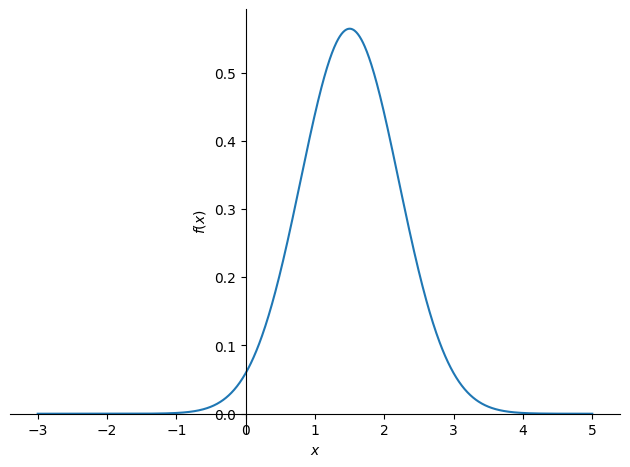

In [19]:
from sympy import *
from sympy.stats import *
mixed = Normal('n1', 1, 1) / 2 +  Normal('n2', 2, 1) / 2
x = symbols("x")
d = density(mixed)(x)
plot(d, (x, -3, 5))

In [20]:
from sympy.stats import sample_iter, Bernoulli

def flip(p, n):
    return list(map(lambda x: 'H' if x==1 else 'T', sample_iter(Bernoulli('X', p), numsamples=n)))

print(flip(0.8, 10)) # p = 0.8 and nsamples=10
# ['H', 'H', 'T', 'H', 'H', 'T', 'H', 'H', 'H', 'H']


print([i for i in sample_iter(Bernoulli('X', 0.8), numsamples=10)])


['H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
[np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]


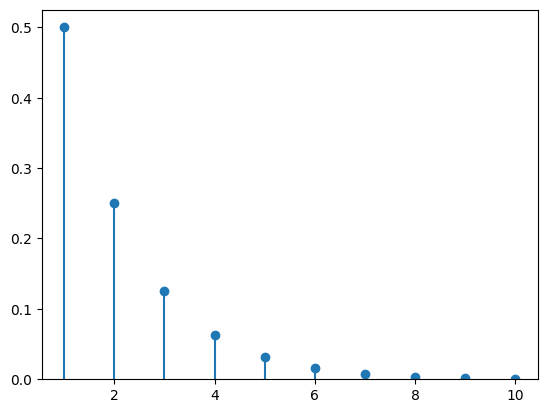

In [21]:
from scipy import stats

X = stats.geom( 0.5 )     # use a geometric distribution with p=0.5

import numpy as np
xs = np.arange( 1, 11 )   # specify the range to be 1,2,3,...,10

import matplotlib.pyplot as plt
ys = X.pmf( xs )          # compute the shape of the distribution
plt.plot( xs, ys, 'o' )   # plot circles...
plt.vlines( xs, 0, ys )   # ...and lines
plt.ylim( bottom=0 )      # ensure sensible bottom border
plt.show()

[0.         0.         0.         0.         0.         0.04166667
 0.04166667 0.04166667 0.04166667 0.04166667 0.04166667 0.04166667
 0.04166667 0.04166667 0.04166667 0.04166667 0.04166667 0.04166667
 0.04166667 0.04166667 0.04166667 0.04166667 0.04166667 0.04166667
 0.04166667 0.04166667 0.04166667 0.04166667 0.04166667 0.
 0.         0.         0.         0.        ]


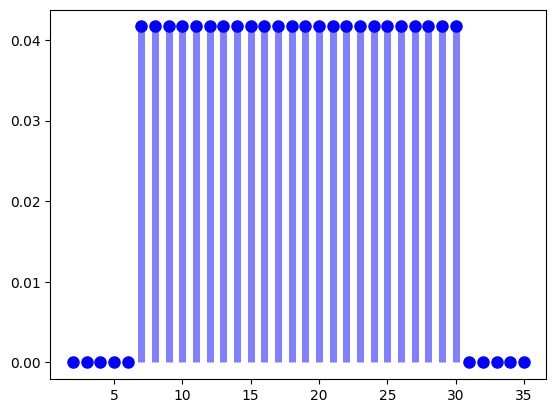

In [22]:
import numpy as np
from scipy.stats import randint
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)

low, high = 7, 31
mean, var, skew, kurt = randint.stats(low, high, moments='mvsk')

x = np.arange(low - 5, high + 5)
ax.plot(x, randint.pmf(x, low, high), 'bo', ms=8, label='randint pmf')
ax.vlines(x, 0, randint.pmf(x, low, high), colors='b', lw=5, alpha=0.5)
print(randint.pmf(x, low, high))

[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
[0.02777778 0.05555556 0.08333333 0.11111111 0.13888889 0.16666667
 0.13888889 0.11111111 0.08333333 0.05555556 0.02777778]


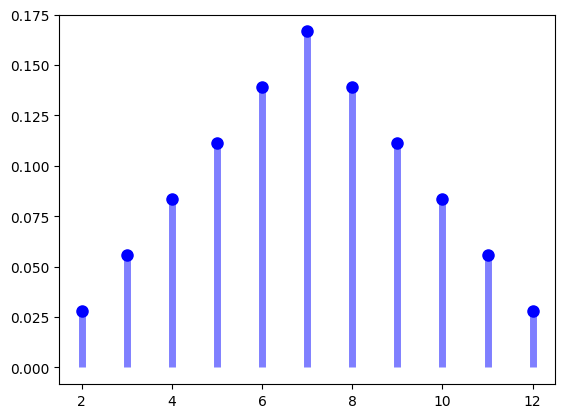

In [23]:
import numpy as np
from scipy.stats import randint
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)

low, high = 1,12
mean, var, skew, kurt = randint.stats(low, high, moments='mvsk')

x = np.arange(1,7)
y = np.arange(1, 7)

xrv = randint.pmf(x,1,7)
yrv = randint.pmf(x, 1, 7)
print(xrv)

xaxis = np.arange(2,13)

xy = np.convolve(xrv,yrv)
print(xy)

ax.plot(xaxis, xy, 'bo', ms=8, label='randint pmf')
ax.vlines(xaxis, 0, xy, colors='b', lw=5, alpha=0.5)

# ax.plot(x, randint.pmf(xy, low, high), 'bo', ms=8, label='randint pmf')
# print(randint.pmf(x, low, high))


Text(0, 0.5, '$p$')

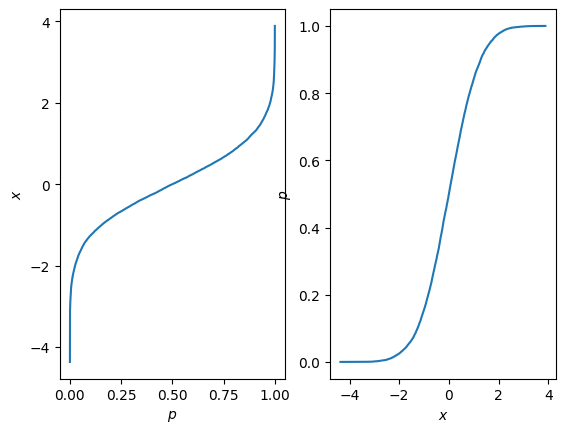

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# create some randomly ddistributed data:
data = np.random.randn(10000)

# sort the data:
data_sorted = np.sort(data)

# calculate the proportional values of samples
p = 1. * np.arange(len(data)) / (len(data) - 1)

# plot the sorted data:
fig = plt.figure()
ax1 = fig.add_subplot(121)
ax1.plot(p, data_sorted)
ax1.set_xlabel('$p$')
ax1.set_ylabel('$x$')

ax2 = fig.add_subplot(122)
ax2.plot(data_sorted, p)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$p$')

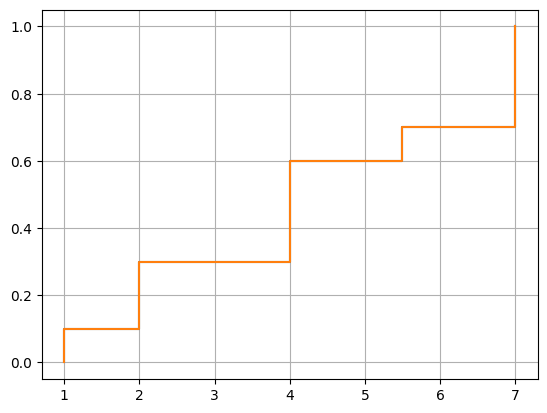

In [25]:
# https://stackoverflow.com/questions/24788200/calculate-the-cumulative-distribution-function-cdf-in-python

import numpy as np
import pandas as pd

def ecdf(a):
    x, counts = np.unique(a, return_counts=True)
    cusum = np.cumsum(counts)
    return x, cusum / cusum[-1]

import matplotlib.pyplot as plt

def plot_ecdf(a):
    x, y = ecdf(a)
    x = np.insert(x, 0, x[0])
    y = np.insert(y, 0, 0.)
    plt.plot(x, y, drawstyle='steps-post')
    plt.grid(True)

xvec = np.array([7,1,2,2,7,4,4,4,5.5,7])
plot_ecdf(xvec)

df = pd.DataFrame({'x':[7,1,2,2,7,4,4,4,5.5,7]})
plot_ecdf(df['x'])

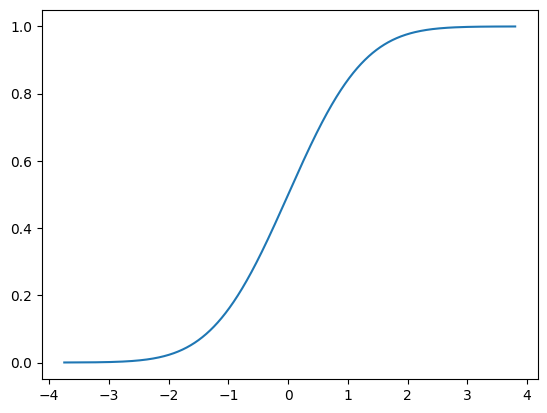

[0.31875215 0.97960951 0.7948013  0.69090036 0.46740215 0.99338693
 0.72401959 0.77738202 0.71569331 0.34871677]


In [26]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

x = np.random.randn(10000) # generate samples from normal distribution (discrete data)
norm_cdf = scipy.stats.norm.cdf(x) # calculate the cdf - also discrete

# plot the cdf
sns.lineplot(x=x, y=norm_cdf)
plt.show()
print(norm_cdf[:10])

In [27]:
mu = np.zeros(2) # mean vector
cov = np.array([[1,0.6],[0.6,1]]) # covariance matrix
# generate 2d normally distributed samples using 0 mean and the covariance matrix above
x = np.random.multivariate_normal(mean=mu, cov=cov, size=1000) # 1000 samples
norm_cdf = scipy.stats.norm.cdf(x)
print(norm_cdf.shape)

(1000, 2)


In [28]:
import numpy as np
pdf, bin_edges = np.histogram(
   data,        # array of data
   bins=500,    # specify the number of bins for distribution function
   density=True # True to return probability density function (pdf) instead of count
   )

cdf = np.cumsum(pdf*np.diff(bin_edges))
cdf

array([1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04,
       1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04,
       1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04,
       1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04,
       1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04,
       1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04,
       1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04, 1.000e-04,
       1.000e-04, 1.000e-04, 2.000e-04, 2.000e-04, 2.000e-04, 2.000e-04,
       2.000e-04, 2.000e-04, 2.000e-04, 2.000e-04, 2.000e-04, 2.000e-04,
       3.000e-04, 3.000e-04, 3.000e-04, 4.000e-04, 4.000e-04, 4.000e-04,
       4.000e-04, 4.000e-04, 4.000e-04, 4.000e-04, 4.000e-04, 5.000e-04,
       5.000e-04, 5.000e-04, 5.000e-04, 5.000e-04, 5.000e-04, 5.000e-04,
       6.000e-04, 6.000e-04, 6.000e-04, 6.000e-04, 8.000e-04, 8.000e-04,
       9.000e-04, 1.300e-03, 1.300e-03, 1.400e-03, 

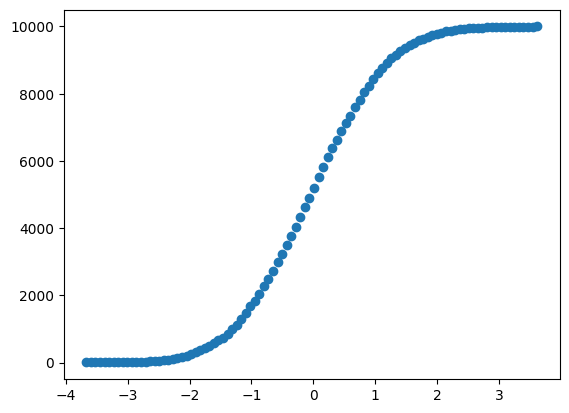

In [29]:
def empirical_cdf(s: pd.Series, n_bins: int = 100):
    # Sort the data into `n_bins` evenly spaced bins:
    discretized = pd.cut(s, n_bins)
    # Count the number of datapoints in each bin:
    bin_counts = discretized.value_counts().sort_index().reset_index()
    # Calculate the locations of each bin as just the mean of the bin start and end:
    bin_counts["loc"] = (pd.IntervalIndex(bin_counts["index"]).left + pd.IntervalIndex(bin_counts["index"]).right) / 2
    # Compute the CDF with cumsum:
    return bin_counts.set_index("loc").iloc[:, -1].cumsum()

s = pd.Series(np.random.randn(10000))
cdf = empirical_cdf(s, n_bins=100)
fig, ax = plt.subplots()
ax.scatter(cdf.index, cdf.values)

(-0.01, 1.01)

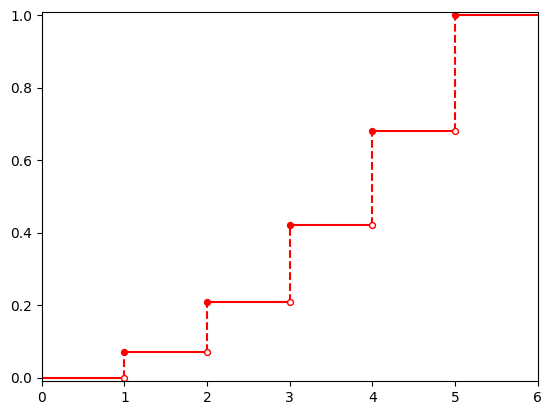

In [30]:
import numpy as np
import matplotlib.pyplot as plt

data = np.arange(0, 7)
y = np.array([.07, .21, .42, .68, 1.])
yn = np.insert(y, 0, 0)

fig, ax = plt.subplots()
ax.set_facecolor('white')

# https://matplotlib.org/api/_as_gen/matplotlib.axes.Axes.hlines.html
ax.hlines(y=yn, xmin=data[:-1], xmax=data[1:],
          color='red', zorder=1)

# https://matplotlib.org/api/_as_gen/matplotlib.axes.Axes.vlines.html
ax.vlines(x=data[1:-1], ymin=yn[:-1], ymax=yn[1:], color='red',
          linestyle='dashed', zorder=1)

ax.scatter(data[1:-1], y, color='red', s=18, zorder=2)
ax.scatter(data[1:-1], yn[:-1], color='white', s=18, zorder=2,
           edgecolor='red')
ax.grid(False)
ax.set_xlim(data[0], data[-1])
ax.set_ylim([-0.01, 1.01])